In [38]:
import pandas as pd
import nltk
import re
import spacy
import numpy as np
from matplotlib import pyplot as plt

nltk.download('stopwords')
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, roc_curve, auc
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.naive_bayes import BernoulliNB

eng = spacy.load('en_core_web_sm')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\gergi_6afqda2\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [3]:
data = pd.read_csv('imdb.csv')

data['sentiment'] = data['sentiment'].apply(lambda x: 1 if x == 'positive' else 0).astype('int8')
data.head()
data = data.iloc[data.index[1::4]]
data.info()


<class 'pandas.core.frame.DataFrame'>
Index: 12500 entries, 1 to 49997
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     12500 non-null  object
 1   sentiment  12500 non-null  int8  
dtypes: int8(1), object(1)
memory usage: 207.5+ KB


**Зменшив об'єм датасету, не вистачає пам'яті**

In [5]:
#nltk
corpus = []
for i in data['review']:
    review = re.sub('[^a-zA-z]',' ',i)
    review = review.lower()
    review = review.split()
    ps = PorterStemmer()
    stwords = stopwords.words('english')
    stwords.remove("not")
    review = [ps.stem(word) for word in review if word not in stwords]
    review = ' '.join(review)
    corpus.append(review)

**Препроцесінг та збереження перетворень до змінної з nltk стеммінгом**

In [39]:
#nltk
cv = CountVectorizer()
X = cv.fit_transform(corpus).toarray()
y = data.iloc[:,1].values

**Bag of words**

In [40]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.66, random_state=17)

**Поділ датасету**

In [41]:
modelDataNltk = []

**List для збереження результатів**

In [42]:
#LogisticRegression
classifier = LogisticRegression()
classifier.fit(X_train, y_train)

y_predproba = classifier.predict_proba(X_test)
y_pred = classifier.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

score1 = accuracy_score(y_test,y_pred)
score2 = precision_score(y_test,y_pred)
score3= recall_score(y_test,y_pred)

print("Accuracy is ",round(score1*100,2),"%")
print("Precision is ",round(score2,2))
print("Recall is ",round(score3,2))

precision = score2
recall = score3

if precision + recall == 0:
    f1_score = 0
else:
    f1_score = 2 * (precision * recall) / (precision + recall)

print("F1 Score is ", round(f1_score, 2))


modelDataNltk.append({"model_name": "LogisticRegression",
                      "Confusion Matrix": cm,
                          "y_test":y_test,
    "y_pred":y_pred,
    "y_pred_proba":y_predproba,
               "accuracy": round(score1*100,2),
               "precision": round(score2,2),
               "recall": round(score3,2),
               "f1-score":round(f1_score, 2)
              })

C:\Users\gergi_6afqda2\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Accuracy is  85.15 %
Precision is  0.85
Recall is  0.85
F1 Score is  0.85


**Тут і далі тренуємо nltk моделі для подальшого порівняння, зберігаємо predproba для графіків в кінці**

In [43]:
# KNN model
knn_classifier = KNeighborsClassifier()
knn_classifier.fit(X_train, y_train)

y_predproba = classifier.predict_proba(X_test)

y_pred_knn = knn_classifier.predict(X_test)
cm_knn = confusion_matrix(y_test, y_pred_knn)

score1_knn = accuracy_score(y_test, y_pred_knn)
score2_knn = precision_score(y_test, y_pred_knn)
score3_knn = recall_score(y_test, y_pred_knn)

print("Accuracy is ", round(score1_knn * 100, 2), "%")
print("Precision is ", round(score2_knn, 2))
print("Recall is ", round(score3_knn, 2))

precision_knn = score2_knn
recall_knn = score3_knn

if precision_knn + recall_knn == 0:
    f1_score_knn = 0
else:
    f1_score_knn = 2 * (precision_knn * recall_knn) / (precision_knn + recall_knn)

print("F1 Score is ", round(f1_score_knn, 2))

modelDataNltk.append({
    "model_name": "KNeighborsClassifier",
    "Confusion Matrix": cm_knn,
        "y_test":y_test,
    "y_pred":y_pred_knn,
    "y_pred_proba":y_predproba,
    "accuracy": round(score1_knn * 100, 2),
    "precision": round(score2_knn, 2),
    "recall": round(score3_knn, 2),
    "f1-score": round(f1_score_knn, 2)
})

Accuracy is  58.16 %
Precision is  0.6
Recall is  0.44
F1 Score is  0.51


In [44]:
# Random Forest
classifier = RandomForestClassifier()
classifier.fit(X_train, y_train)

y_predproba = classifier.predict_proba(X_test)
y_pred = classifier.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

score1 = accuracy_score(y_test, y_pred)
score2 = precision_score(y_test, y_pred)
score3 = recall_score(y_test, y_pred)

print("Accuracy is ", round(score1 * 100, 2), "%")
print("Precision is ", round(score2, 2))
print("Recall is ", round(score3, 2))

precision = score2
recall = score3

if precision + recall == 0:
    f1_score = 0
else:
    f1_score = 2 * (precision * recall) / (precision + recall)

print("F1 Score is ", round(f1_score, 2))

modelDataNltk.append({
    "model_name": "RandomForest",
    "Confusion Matrix": cm,
        "y_test":y_test,
    "y_pred":y_pred,
    "y_pred_proba":y_predproba,
    "accuracy": round(score1 * 100, 2),
    "precision": round(score2, 2),
    "recall": round(score3, 2),
    "f1-score": round(f1_score, 2)
})

Accuracy is  84.02 %
Precision is  0.84
Recall is  0.83
F1 Score is  0.84


In [45]:
# Multinomial Naive Bayes
classifier = MultinomialNB()
classifier.fit(X_train, y_train)

y_predproba = classifier.predict_proba(X_test)
y_pred = classifier.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

score1 = accuracy_score(y_test, y_pred)
score2 = precision_score(y_test, y_pred)
score3 = recall_score(y_test, y_pred)

print("Accuracy is ", round(score1 * 100, 2), "%")
print("Precision is ", round(score2, 2))
print("Recall is ", round(score3, 2))

precision = score2
recall = score3

if precision + recall == 0:
    f1_score = 0
else:
    f1_score = 2 * (precision * recall) / (precision + recall)

print("F1 Score is ", round(f1_score, 2))

modelDataNltk.append({
    "model_name": "MultinomialNaiveBayes",
    "Confusion Matrix": cm,
        "y_test":y_test,
    "y_pred":y_pred,
    "y_pred_proba":y_predproba,
    "accuracy": round(score1 * 100, 2),
    "precision": round(score2, 2),
    "recall": round(score3, 2),
    "f1-score": round(f1_score, 2)
})

Accuracy is  83.27 %
Precision is  0.85
Recall is  0.8
F1 Score is  0.82


In [46]:
# Bernoulli Naive Bayes classifier
classifier = BernoulliNB()
classifier.fit(X_train, y_train)

y_predproba = classifier.predict_proba(X_test)
y_pred = classifier.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

score1 = accuracy_score(y_test, y_pred)
score2 = precision_score(y_test, y_pred)
score3 = recall_score(y_test, y_pred)

print("Accuracy is ", round(score1 * 100, 2), "%")
print("Precision is ", round(score2, 2))
print("Recall is ", round(score3, 2))

precision = score2
recall = score3

if precision + recall == 0:
    f1_score = 0
else:
    f1_score = 2 * (precision * recall) / (precision + recall)

print("F1 Score is ", round(f1_score, 2))

# Append results to the modelDataNltk list
modelDataNltk.append({
    "model_name": "BernoulliNaiveBayes",
    "Confusion Matrix": cm,
        "y_test":y_test,
    "y_pred":y_pred,
    "y_pred_proba":y_predproba,
    "accuracy": round(score1 * 100, 2),
    "precision": round(score2, 2),
    "recall": round(score3, 2),
    "f1-score": round(f1_score, 2)
})

Accuracy is  83.11 %
Precision is  0.86
Recall is  0.79
F1 Score is  0.82


In [47]:
#spaCy
corpus_spacy = []
for i in data['review']:
    review = re.sub('[^a-zA-z]',' ',i)
    review = review.lower()
    stwords = stopwords.words('english')
    stwords.remove("not")
    review = eng(review)
    review = [token.lemma_ for token in review if str(token) not in stwords]
    review = ' '.join(review)
    corpus_spacy.append(review)

**Повторюємо але вже зі застосуванням токенізації, лематизації spaCy**

In [48]:
modelDataSpacy = []

In [49]:
#spacy
cv = CountVectorizer()
X = cv.fit_transform(corpus_spacy).toarray()
y = data.iloc[:,1].values

In [50]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.66, random_state=42)

In [51]:
#LogisticRegression
classifier = LogisticRegression()
classifier.fit(X_train, y_train)

y_predproba = classifier.predict_proba(X_test)
y_pred = classifier.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

score1 = accuracy_score(y_test,y_pred)
score2 = precision_score(y_test,y_pred)
score3= recall_score(y_test,y_pred)

print("Accuracy is ",round(score1*100,2),"%")
print("Precision is ",round(score2,2))
print("Recall is ",round(score3,2))

precision = score2
recall = score3

if precision + recall == 0:
    f1_score = 0
else:
    f1_score = 2 * (precision * recall) / (precision + recall)

print("F1 Score is ", round(f1_score, 2))


modelDataSpacy.append({"model_name": "LogisticRegression",
                                             "Confusion Matrix": cm,
                       "y_test":y_test,
    "y_pred":y_pred,
    "y_pred_proba":y_predproba,
               "accuracy": round(score1*100,2),
               "precision": round(score2,2),
               "recall": round(score3,2),
               "f1-score":round(f1_score, 2)
              })

C:\Users\gergi_6afqda2\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Accuracy is  85.76 %
Precision is  0.85
Recall is  0.86
F1 Score is  0.86


In [52]:
# K Nearest Neighbors
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score

classifier = KNeighborsClassifier(n_neighbors=5)
classifier.fit(X_train, y_train)

y_predproba =  classifier.predict_proba(X_test)
y_pred = classifier.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

score1 = accuracy_score(y_test, y_pred)
score2 = precision_score(y_test, y_pred)
score3 = recall_score(y_test, y_pred)

print("Accuracy is ", round(score1 * 100, 2), "%")
print("Precision is ", round(score2, 2))
print("Recall is ", round(score3, 2))

precision = score2
recall = score3

if precision + recall == 0:
    f1_score = 0
else:
    f1_score = 2 * (precision * recall) / (precision + recall)

print("F1 Score is ", round(f1_score, 2))

modelDataSpacy.append({"model_name": "KNeighborsClassifier",
                       "Confusion Matrix": cm,
                       "y_test":y_test,
    "y_pred":y_pred,
    "y_pred_proba":y_predproba,
                       "accuracy": round(score1 * 100, 2),
                       "precision": round(score2, 2),
                       "recall": round(score3, 2),
                       "f1-score": round(f1_score, 2)
                       })

Accuracy is  59.79 %
Precision is  0.6
Recall is  0.53
F1 Score is  0.56


In [53]:
# RandomForestClassifier
classifier = RandomForestClassifier()
classifier.fit(X_train, y_train)

y_predproba = classifier.predict_proba(X_test)
y_pred = classifier.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

score1 = accuracy_score(y_test, y_pred)
score2 = precision_score(y_test, y_pred)
score3 = recall_score(y_test, y_pred)

print("Accuracy is ", round(score1 * 100, 2), "%")
print("Precision is ", round(score2, 2))
print("Recall is ", round(score3, 2))

precision = score2
recall = score3

if precision + recall == 0:
    f1_score = 0
else:
    f1_score = 2 * (precision * recall) / (precision + recall)

print("F1 Score is ", round(f1_score, 2))

modelDataSpacy.append({"model_name": "RandomForest",
                       "Confusion Matrix": cm,
                           "y_test":y_test,
    "y_pred":y_pred,
    "y_pred_proba":y_predproba,
                       "accuracy": round(score1 * 100, 2),
                       "precision": round(score2, 2),
                       "recall": round(score3, 2),
                       "f1-score": round(f1_score, 2)
                       })

Accuracy is  83.74 %
Precision is  0.85
Recall is  0.82
F1 Score is  0.83


In [54]:
# Multinomial Naive Bayes
classifier = MultinomialNB()
classifier.fit(X_train, y_train)

y_predproba = classifier.predict_proba(X_test)
y_pred = classifier.predict(X_test)
cm = confusion_matrix(y_test, y_pred)


score1 = accuracy_score(y_test, y_pred)
score2 = precision_score(y_test, y_pred)
score3 = recall_score(y_test, y_pred)

print("Accuracy is ", round(score1 * 100, 2), "%")
print("Precision is ", round(score2, 2))
print("Recall is ", round(score3, 2))

precision = score2
recall = score3

if precision + recall == 0:
    f1_score = 0
else:
    f1_score = 2 * (precision * recall) / (precision + recall)

print("F1 Score is ", round(f1_score, 2))

modelDataSpacy.append({
    "model_name": "MultinomialNaiveBayes",
    "Confusion Matrix": cm,
    "y_test":y_test,
    "y_pred":y_pred,
    "y_pred_proba":y_predproba,
    "accuracy": round(score1 * 100, 2),
    "precision": round(score2, 2),
    "recall": round(score3, 2),
    "f1-score": round(f1_score, 2)
})

Accuracy is  83.65 %
Precision is  0.86
Recall is  0.8
F1 Score is  0.83


In [55]:
modelDataNltkDF = pd.DataFrame(modelDataNltk)
modelDataNltkDF

,model_name,Confusion Matrix,y_test,y_pred,y_pred_proba,accuracy,precision,recall,f1-score
0,LogisticRegression,"[[1848, 318], [313, 1771]]","[0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, ...","[0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, ...","[[0.9998469743163735, 0.0001530256836265258], ...",85.15,0.85,0.85,0.85
1,KNeighborsClassifier,"[[1554, 612], [1166, 918]]","[0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, ...","[0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, ...","[[0.9998469743163735, 0.0001530256836265258], ...",58.16,0.60,0.44,0.51
2,RandomForest,"[[1837, 329], [350, 1734]]","[0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, ...","[0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, ...","[[0.76, 0.24], [0.39, 0.61], [0.34, 0.66], [0....",84.02,0.84,0.83,0.84
3,MultinomialNaiveBayes,"[[1865, 301], [410, 1674]]","[0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, ...","[0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, ...","[[0.9999795667888839, 2.0433211133430853e-05],...",83.27,0.85,0.80,0.82
4,BernoulliNaiveBayes,"[[1892, 274], [444, 1640]]","[0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, ...","[0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, ...","[[0.9999919878891125, 8.012110899147042e-06], ...",83.11,0.86,0.79,0.82


**Тут найкращою виявилась логістична регресія**

In [56]:
modelDataSpacyDF = pd.DataFrame(modelDataSpacy)
modelDataSpacyDF

,model_name,Confusion Matrix,y_test,y_pred,y_pred_proba,accuracy,precision,recall,f1-score
0,LogisticRegression,"[[1836, 322], [283, 1809]]","[1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, ...","[0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, ...","[[0.7862444697318228, 0.21375553026817717], [0...",85.76,0.85,0.86,0.86
1,KNeighborsClassifier,"[[1437, 721], [988, 1104]]","[1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, ...","[0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, ...","[[0.8, 0.2], [0.6, 0.4], [0.8, 0.2], [0.4, 0.6...",59.79,0.60,0.53,0.56
2,RandomForest,"[[1844, 314], [377, 1715]]","[1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, ...","[1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, ...","[[0.46, 0.54], [0.2, 0.8], [0.72, 0.28], [0.43...",83.74,0.85,0.82,0.83
3,MultinomialNaiveBayes,"[[1888, 270], [425, 1667]]","[1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, ...","[1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, ...","[[0.04983023769190027, 0.9501697623080915], [0...",83.65,0.86,0.80,0.83


**За допомогою спейсі теж найкраща логістична регресія, spaCy за підсумком трохи краще за nltk**

In [57]:
modelDataNltk = modelDataNltkDF.to_dict('list')
modelDataSpacyDF = modelDataSpacyDF.to_dict('list')

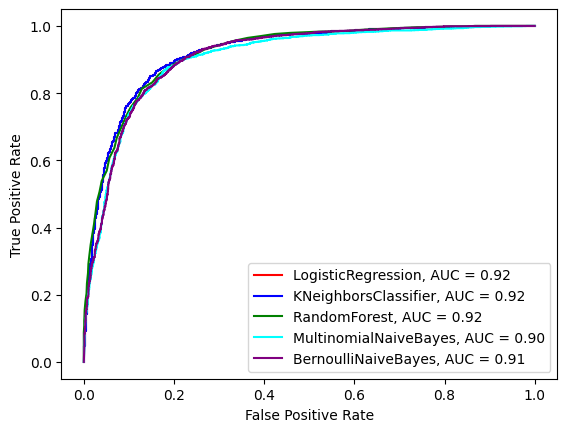

In [59]:
df = pd.DataFrame(modelDataNltkDF)
def plot(df):
    fig, ax = plt.subplots()

    colors = {
            'LogisticRegression': 'red',
            'KNeighborsClassifier': 'blue',
            'RandomForest': 'green',
            'MultinomialNaiveBayes': 'cyan',
            'BernoulliNaiveBayes': 'purple'
    }

    for i, model in enumerate(df['model_name']):
        fpr, tpr, _ = roc_curve(df['y_test'][i], df['y_pred_proba'][i][:, 1])
        roc_auc = auc(fpr, tpr)
        label = '{}, AUC = {:.2f}'.format(model, roc_auc)
        ax.plot(fpr, tpr, color=colors[model], label=label)

    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(loc='lower right')
    plt.show()
plot(df)

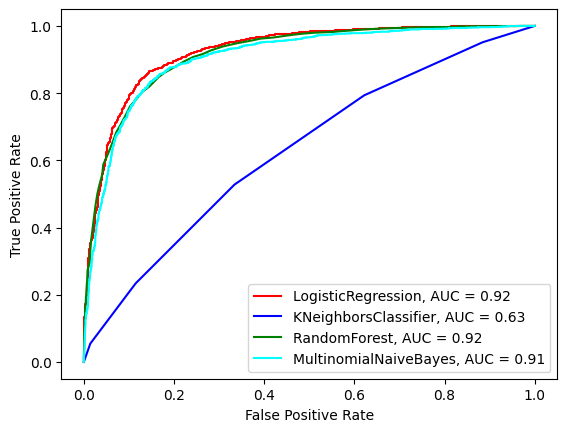

In [60]:
df = pd.DataFrame(modelDataSpacyDF)
plot(df)


**Графіки підтверджують попередні твердження**